In [1]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
 95% 747M/787M [00:06<00:00, 88.5MB/s]
100% 787M/787M [00:06<00:00, 120MB/s] 


In [3]:
!unzip kaggle-cat-vs-dog-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5489.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/549.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5490.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5491.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5492.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5493.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5494.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5495.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5496.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5497.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5498.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5499.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/55.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/550.jpg  
  inflating: kagglecatsanddogs_3367a/PetImages/Dog/5500.jpg  
  inflating: kagglecats

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [5]:
import os
import shutil
import random

source_dir = "/content/kagglecatsanddogs_3367a/PetImages"

train_dir = "dataset/train"
test_dir = "dataset/test"

classes = ["Cat", "Dog"]

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    files = os.listdir(os.path.join(source_dir, cls))
    random.shuffle(files)

    split = int(0.8 * len(files))

    train_files = files[:split]
    test_files = files[split:]

    for f in train_files:
        shutil.copy(os.path.join(source_dir, cls, f),
                    os.path.join(train_dir, cls, f))

    for f in test_files:
        shutil.copy(os.path.join(source_dir, cls, f),
                    os.path.join(test_dir, cls, f))

print("Dataset split completed.")

Dataset split completed.


In [6]:
import os
from PIL import Image

dataset_dir = "kagglecatsanddogs_3367a/PetImages"

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(dataset_dir, folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            img = Image.open(fpath)
            img.verify()
        except:
            num_skipped += 1
            os.remove(fpath)

print("Deleted corrupted images:", num_skipped)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Deleted corrupted images: 2


In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 24959 files belonging to 2 classes.
Using 19968 files for training.
Found 24959 files belonging to 2 classes.
Using 4991 files for validation.


In [8]:
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

# Normalize our image between the values of 0 and 1

In [9]:
def process(image,label):
  image= tf.cast(image/255.,tf.float32)
  return image,label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

# Creating a CNN model

In [ ]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

# FC layers
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
    618/Unknown 38s 55ms/step - accuracy: 0.5840 - loss: 0.6860

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 47s 70ms/step - accuracy: 0.5841 - loss: 0.6859 - val_accuracy: 0.7560 - val_loss: 0.5000
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 76s 64ms/step - accuracy: 0.7728 - loss: 0.4742 - val_accuracy: 0.7928 - val_loss: 0.4363
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 76s 124ms/step - accuracy: 0.8244 - loss: 0.3806 - val_accuracy: 0.8161 - val_loss: 0.4213
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8878 - loss: 0.2654 - val_accuracy: 0.8042 - val_loss: 0.5979
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9359 - loss: 0.1590 - val_accuracy: 0.7930 - val_loss: 0.7932
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9685 - loss: 0.0909 - val_accuracy: 0.7976 - val_loss: 0.9678
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9777 - loss: 0.0616 - val_accuracy: 0.7868 - val_loss: 1.1959
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9852 - loss: 0.0481 - val_accura

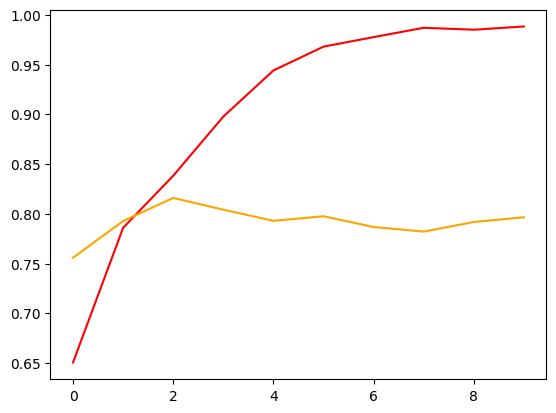

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='orange',label='test')

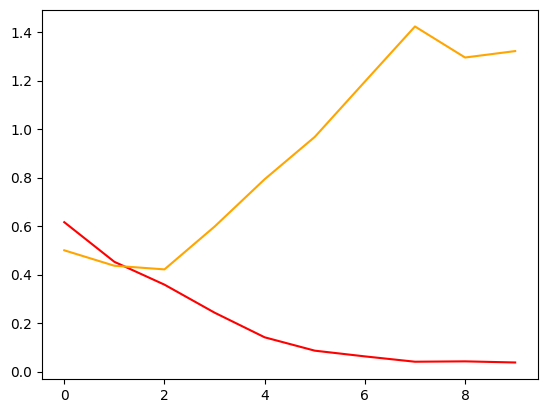

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='orange',label='test')

# To reduce overfitting

In [ ]:
from keras.layers import BatchNormalization,Dropout

In [ ]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

# FC layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,177 (42.64 MB)

 Trainable params: 11,177,729 (42.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'])
history2 = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
    618/Unknown 46s 63ms/step - accuracy: 0.6042 - loss: 0.7303

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6043 - loss: 0.7302 - val_accuracy: 0.5851 - val_loss: 0.6679
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.7424 - loss: 0.5220 - val_accuracy: 0.7003 - val_loss: 0.5949
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.8096 - loss: 0.4219 - val_accuracy: 0.6620 - val_loss: 0.6070
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8482 - loss: 0.3451 - val_accuracy: 0.7720 - val_loss: 0.6805
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.8831 - loss: 0.2742 - val_accuracy: 0.7319 - val_loss: 1.1310
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9213 - loss: 0.1920 - val_accuracy: 0.8012 - val_loss: 0.6554
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9501 - loss: 0.1274 - val_accuracy: 0.7952 - val_loss: 0.7227
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.9676 - loss: 0.0892 - val_accura

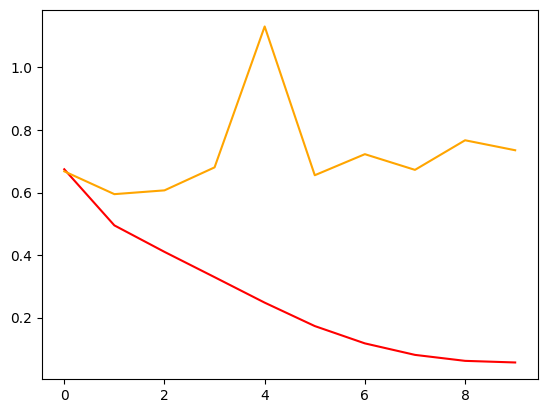

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history2.history['loss'],color='red',label='train')
plt.plot(history2.history['val_loss'],color='orange',label='test')

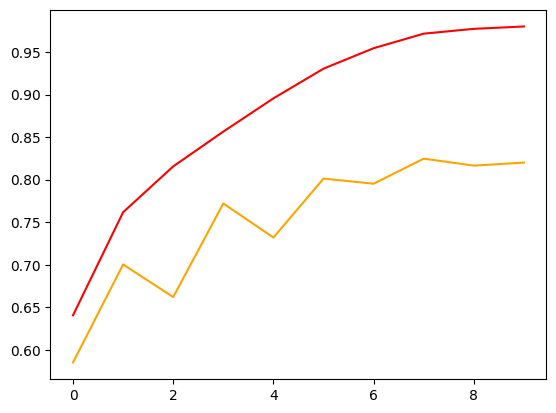

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'],color='red',label='train')
plt.plot(history2.history['val_accuracy'],color='orange',label='test')

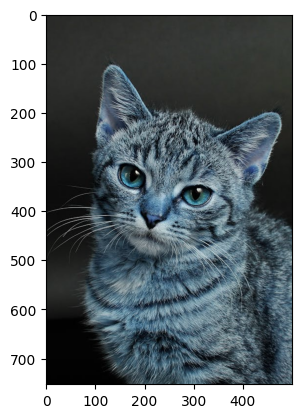

In [ ]:
import cv2
test_img = cv2.imread('/content/cat.jpeg')
plt.imshow(test_img)

In [ ]:
test_img.shape

(753, 500, 3)

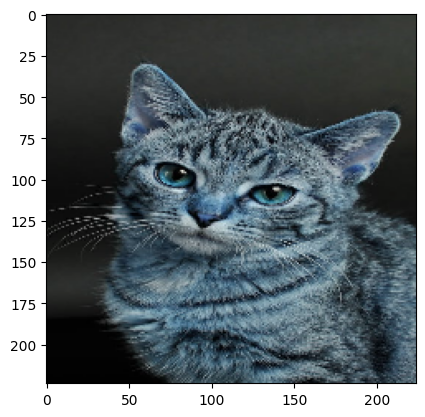

In [ ]:
test_img = cv2.resize(test_img,(224,224))
plt.imshow(test_img)

In [ ]:
test_input = test_img.reshape((1,224,224,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[0.]], dtype=float32)

# Applying data augmentation

In [ ]:
from keras.layers import RandomFlip,RandomZoom,RandomContrast
data_aug = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
model = Sequential()
model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_aug)
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

# FC layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))
model.summary()

In [ ]:
model.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'],)
history3 = model.fit(train_ds,epochs=20,validation_data=val_ds,callbacks=[early_stop])

In [ ]:
  import matplotlib.pyplot as plt
  plt.plot(history3.history['accuracy'],color='red',label='train')
  plt.plot(history3.history['val_accuracy'],color='black',label='test')

# Applying Transfer Leanring

1.Feature Extraction - only the fc layers will be ours

In [10]:
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16

In [11]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
from keras.layers import RandomFlip,RandomZoom,RandomContrast
data_aug = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dropout
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [25]:
# making our model wiht the conv_base
model = Sequential()
model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_aug)
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
conv_base.trainable = False

In [27]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [31]:
history = model.fit(train_ds,validation_data=val_ds,epochs=20,callbacks=[early_stop])

Epoch 1/20
    618/Unknown 103s 167ms/step - accuracy: 0.8880 - loss: 0.2680

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 132s 214ms/step - accuracy: 0.8880 - loss: 0.2679 - val_accuracy: 0.9311 - val_loss: 0.1778
Epoch 2/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 138s 223ms/step - accuracy: 0.9261 - loss: 0.1745 - val_accuracy: 0.9307 - val_loss: 0.1669
Epoch 3/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 125s 203ms/step - accuracy: 0.9386 - loss: 0.1500 - val_accuracy: 0.9355 - val_loss: 0.1587
Epoch 4/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 124s 201ms/step - accuracy: 0.9453 - loss: 0.1312 - val_accuracy: 0.9321 - val_loss: 0.1639
Epoch 5/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 125s 202ms/step - accuracy: 0.9488 - loss: 0.1222 - val_accuracy: 0.9203 - val_loss: 0.2033
Epoch 6/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - accuracy: 0.9505 - loss: 0.1187 - val_accuracy: 0.9377 - val_loss: 0.1523
Epoch 7/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 125s 203ms/step - accuracy: 0.9574 - loss: 0.1036 - val_accuracy: 0.9379 - val_loss: 0.1492
Epoch 8/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 125s 202ms/step - accuracy: 0.9623 - loss: 0.09

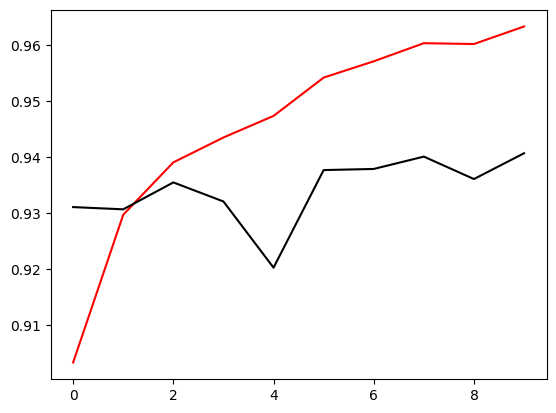

In [32]:
plt.plot(history.history['accuracy'],color='red',label='test')
plt.plot(history.history['val_accuracy'],color='black',label='train')

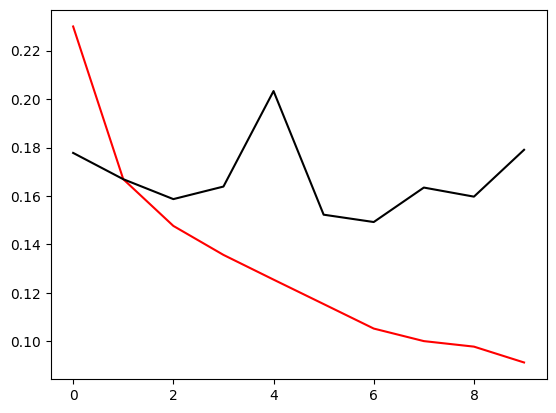

In [33]:
plt.plot(history.history['loss'],color='red',label='test')
plt.plot(history.history['val_loss'],color='black',label='train')